### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/c8bda808fac2419d8025370763a90ada) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceceliashalinidsouza","key":"ea10233ed83aa980843f052ecc7da20c"}'}

In [ ]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json   sample_submission.csv  to-classify-tones-of-musical-emotion-files.zip
sample_data/  Test/                  Train/


### 4. Install the Kaggle API using the following command


In [ ]:
!pip install -U -q kaggle==1.5.8

### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [ ]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c to-classify-tones-of-musical-emotion-files
!unzip to-classify-tones-of-musical-emotion-files.zip

 99% 636M/641M [00:06<00:00, 164MB/s]
100% 641M/641M [00:06<00:00, 101MB/s]
Archive:  to-classify-tones-of-musical-emotion-files.zip
  inflating: Test/Test/1.wav         
  inflating: Test/Test/10.wav        
  inflating: Test/Test/100.wav       
  inflating: Test/Test/101.wav       
  inflating: Test/Test/102.wav       
  inflating: Test/Test/103.wav       
  inflating: Test/Test/104.wav       
  inflating: Test/Test/105.wav       
  inflating: Test/Test/106.wav       
  inflating: Test/Test/107.wav       
  inflating: Test/Test/108.wav       
  inflating: Test/Test/109.wav       
  inflating: Test/Test/11.wav        
  inflating: Test/Test/110.wav       
  inflating: Test/Test/111.wav       
  inflating: Test/Test/112.wav       
  inflating: Test/Test/113.wav       
  inflating: Test/Test/114.wav       
  inflating: Test/Test/115.wav       
  inflating: Test/Test/116.wav       
  inflating: Test/Test/117.wav       
  inflating: Test/Test/118.wav       
  inflating: Test/Test/119.wav 

### YOUR CODING STARTS FROM HERE

In [ ]:
pip install --upgrade librosa

In [ ]:
# 1. Import Necessary Packages
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve, accuracy_score
from scipy.io import wavfile  # Alternative to soundfile

In [ ]:
# 2. Load Train Data Paths
happy_path = '/content/Train/Train/Happy'
sad_path = '/content/Train/Train/Sad'

def load_data_paths():
    happy_files = [os.path.join(happy_path, f) for f in os.listdir(happy_path) if f.endswith('.wav')]
    sad_files = [os.path.join(sad_path, f) for f in os.listdir(sad_path) if f.endswith('.wav')]
    labels = ['Happy'] * len(happy_files) + ['Sad'] * len(sad_files)
    file_paths = happy_files + sad_files
    return file_paths, labels

file_paths, labels = load_data_paths()
print(f"Total files loaded: {len(file_paths)}")

Total files loaded: 1873


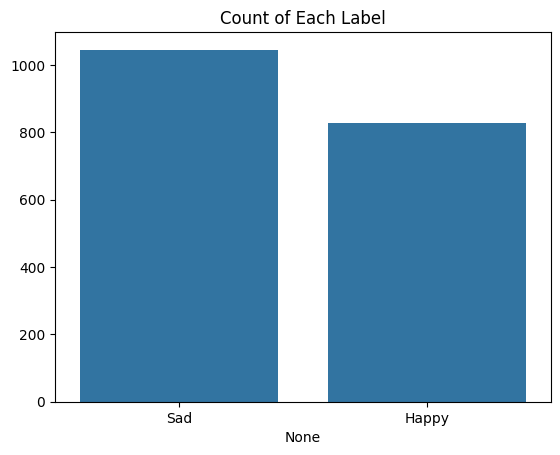

In [ ]:

# 3. Data Exploration and Visualization
# 3.1 Find count of each label and plot bar graph
label_counts = pd.Series(labels).value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Count of Each Label')
plt.show()

<ipython-input-17-050e9d5b2e9f>:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)  # sr=None preserves the original sampling rate
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-17-050e9d5b2e9f>:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)  # sr=None preserves the original sampling rate
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


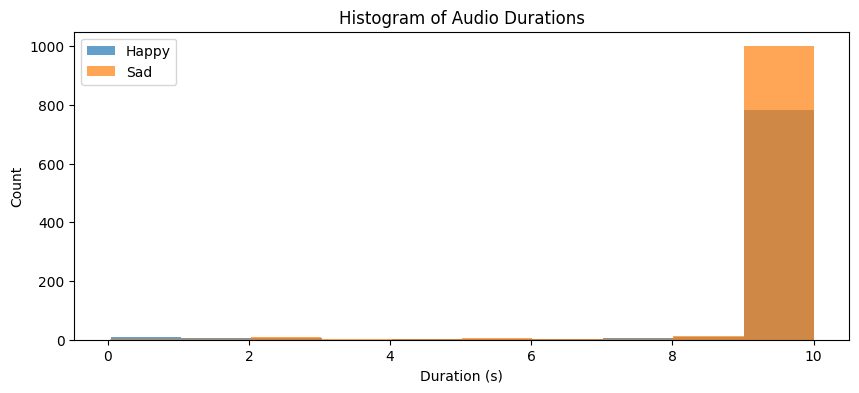

In [ ]:
# 3.2 Histogram of file durations

import librosa

def get_audio_durations(file_paths):
    durations = []
    for file in file_paths:
        try:
            # Load the audio file
            y, sr = librosa.load(file, sr=None)  # sr=None preserves the original sampling rate
            durations.append(librosa.get_duration(y=y, sr=sr))
        except Exception as e:
            print(f"Skipping file {file}: {e}")
    return durations


happy_durations = get_audio_durations([f for f, lbl in zip(file_paths, labels) if lbl == 'Happy'])
sad_durations = get_audio_durations([f for f, lbl in zip(file_paths, labels) if lbl == 'Sad'])

plt.figure(figsize=(10, 4))
plt.hist(happy_durations, bins=10, alpha=0.7, label='Happy')
plt.hist(sad_durations, bins=10, alpha=0.7, label='Sad')
plt.title('Histogram of Audio Durations')
plt.xlabel('Duration (s)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
from IPython.display import Audio
# Function to play audio
def play_audio(file_path):
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None)
        print(f"Playing audio: {file_path}")
        return Audio(y, rate=sr)  # Returns an audio widget
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Example file
sample_file = file_paths[0]  # Selecting the first file from the list
print(sample_file)

# Play the audio
audio_widget = play_audio(sample_file)
if audio_widget:
    display(audio_widget)

/content/Train/Train/Happy/Happy33501.wav
Playing audio: /content/Train/Train/Happy/Happy33501.wav


In [ ]:
# 3.3 Preprocess Audio Files
def preprocess_audio(file, max_duration=10, target_sr=22050):
    try:
        # Load the audio file
        data, sr = librosa.load(file, sr=target_sr)  # Resample to target_sr
        max_length = int(max_duration * sr)  # Maximum number of samples

        # Trim or pad the audio data
        if len(data) > max_length:
            data = data[:max_length]
        elif len(data) < max_length:
            padding = max_length - len(data)
            data = np.pad(data, (0, padding), mode='constant')

        return data, sr
    except Exception as e:
        print(f"Error processing file {file}: {e}")
        return None, None

In [ ]:
# Feature extraction function for music classification
def extract_music_features(file, n_mfcc=40):
    # Load audio file
    y, sr = librosa.load(file, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.mean(mfcc.T, axis=0)  # Mean over time

    # Extract Chromagram
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma.T, axis=0)  # Mean over time

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast.T, axis=0)  # Mean over time

    # Extract Zero Crossing Rate (ZCR)
    zcr = librosa.feature.zero_crossing_rate(y=y)
    zcr = np.mean(zcr.T, axis=0)  # Mean over time

    # Extract Root Mean Square (RMS) Energy
    rms = librosa.feature.rms(y=y)
    rms = np.mean(rms.T, axis=0)  # Mean over time

    # Extract Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_bandwidth = np.mean(spectral_bandwidth.T, axis=0)  # Mean over time

    # Concatenate features
    features = np.hstack([mfcc, chroma, spectral_contrast, zcr, rms, spectral_bandwidth])
    return features

# Extract features for all files
features = [extract_music_features(file) for file in file_paths]
X = np.array(features)
y = np.array(labels)

# Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

<ipython-input-23-9c6939640fc3>:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
<ipython-input-23-9c6939640fc3>:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.10/dist-packages/lib

In [ ]:
print(f"Feature shape: {X.shape}, Label shape: {y.shape}")

Feature shape: (1873, 62), Label shape: (1873,)


## Scaling Features
It’s a good practice to scale the features before feeding them into the model to ensure that all features are on a similar scale, especially since audio features can vary in magnitude:

In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Feature shape: {X.shape}, Label shape: {y.shape}")

Feature shape: (1873, 62), Label shape: (1873,)


In [ ]:
# 4.1 Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training shape: {X_train.shape}, Validation shape: {X_val.shape}")

Training shape: (1498, 62), Validation shape: (375, 62)


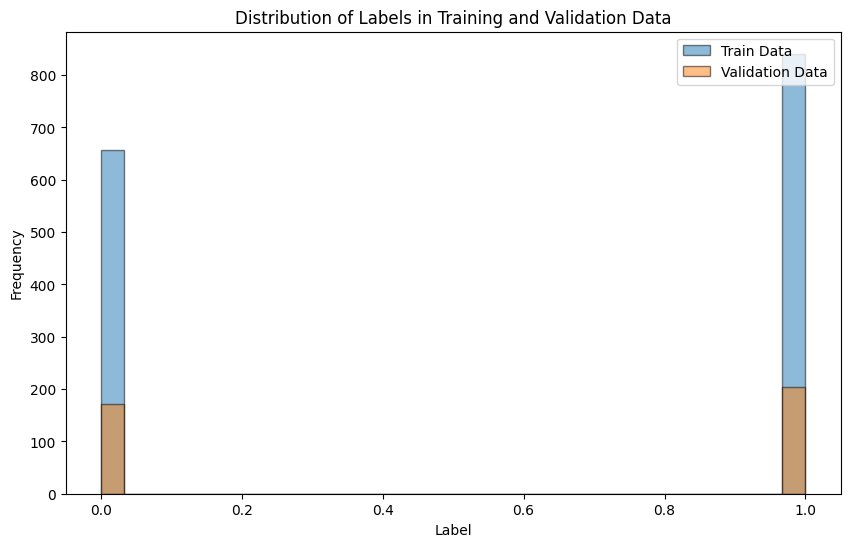

In [ ]:
# Assuming y_train and y_val are your labels (for example, emotion categories or binary labels)
plt.figure(figsize=(10, 6))

# Plot histogram for training data
plt.hist(y_train, alpha=0.5, label='Train Data', bins=30, edgecolor='black')

# Plot histogram for validation data
plt.hist(y_val, alpha=0.5, label='Validation Data', bins=30, edgecolor='black')

plt.title('Distribution of Labels in Training and Validation Data')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.legend(loc='upper right')

plt.show()

In [ ]:
# 5. Create Dataset and DataLoader
class AudioDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
# 6. Define CNN Model with Conv1d
class EmotionCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(16)  # Batch normalization after conv1
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm1d(32)  # Batch normalization after conv1
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)  # Third convolution layer
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm1d(64)  # Batch normalization after conv1

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)


        # Corrected flattened size after convolution and pooling
        # self.flatten_size = 32 * 29  # 32 channels, sequence length 29
        # Update flattened size based on the output shape
        self.flatten_size = 32 * 31  # Correct flattened size
        # self.flatten_size = 64 * 7

        self.fc1 = nn.Linear(self.flatten_size, 128)  # Updated size
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.6)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor before passing to fully connected layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [ ]:
model = EmotionCNN(input_size=X.shape[1], num_classes=2)

In [ ]:
print(model)

EmotionCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=992, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (relu): ReLU()
)


In [ ]:
def get_conv_output_shape(model, input_size):
    with torch.no_grad():
        x = torch.zeros(1, 1, input_size)  # (batch_size, channels, sequence_length)
        x = model.conv1(x)
        x = model.conv2(x)
        x = model.pool(x)
        return x.size()

input_size = X.shape[1]  # Length of the input feature vector
output_shape = get_conv_output_shape(model, input_size)
print("Output shape after conv layers:", output_shape)

Output shape after conv layers: torch.Size([1, 32, 31])


In [ ]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Add weight_decay


In [ ]:
# 6.1 Training


# Training function
def train(model, train_loader, val_loader, epochs, device):
    train_acc, val_acc = [], []
    model.to(device)  # Ensure the model is on the correct device (GPU/CPU)

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        # Training loop
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move data to device
            X_batch = X_batch.unsqueeze(1)  # Reshape to (batch_size, 1, sequence_length)

            optimizer.zero_grad()
            outputs = model(X_batch)  # Forward pass
            loss = criterion(outputs, y_batch)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Optimize weights

            # Calculate accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc.append(correct / total)

        # Validation loop
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch.unsqueeze(1)  # Reshape to (batch_size, 1, sequence_length)

                outputs = model(X_batch)  # Forward pass
                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc.append(correct / total)
        print(f"Epoch {epoch+1}, Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

    return train_acc, val_acc


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [ ]:
train_acc, val_acc = train(model, train_loader, val_loader,7,device)

Epoch 1, Train Acc: 0.6636, Val Acc: 0.7307
Epoch 2, Train Acc: 0.7877, Val Acc: 0.7467
Epoch 3, Train Acc: 0.8184, Val Acc: 0.7893
Epoch 4, Train Acc: 0.8518, Val Acc: 0.7920
Epoch 5, Train Acc: 0.8565, Val Acc: 0.7920
Epoch 6, Train Acc: 0.8678, Val Acc: 0.8000
Epoch 7, Train Acc: 0.8905, Val Acc: 0.8133


In [ ]:

train_acc, val_acc = train(model, train_loader, val_loader,1,device)

Epoch 1, Train Acc: 0.9206, Val Acc: 0.8053


In [ ]:
train_acc, val_acc = train(model, train_loader, val_loader,1,device)

Epoch 1, Train Acc: 0.9179, Val Acc: 0.8187


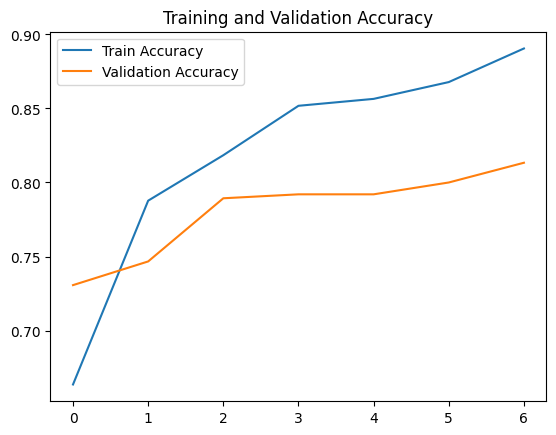

In [ ]:
# 6.1 Plot Training and Validation Accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()


In [ ]:
# 6.2. Kaggle Test Predictions
model.eval()

def load_test_data(test_path, max_duration=10):
    files = [os.path.join(test_path, f) for f in os.listdir(test_path) if f.endswith('.wav')]
    features = [extract_music_features(file) for file in files]  # Ensure this extracts features as expected
    return np.array(features), files

test_path = '/content/Test/Test/'
X_test, test_files = load_test_data(test_path)

# Transform the unseen (test) data using the same scaler
# Only transform, do not fit again as we did with train data same operations to be applied on test data as well
X_test_scaled = scaler.transform(X_test)

# Convert the test data to a tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Ensure the input has the right shape (batch_size, 1, sequence_length)
X_test_tensor = X_test_tensor.unsqueeze(1)  # Adding the channel dimension (1)

# Move test data to the same device as the model
X_test_tensor = X_test_tensor.to(device)

# Get predictions
with torch.no_grad():  # Disable gradient computation for inference
    preds = model(X_test_tensor)
    _, predicted_labels = torch.max(preds, 1)

# Get predicted labels and associate with file names if needed
predicted_labels = predicted_labels.cpu().numpy()  # Move predictions to CPU if on GPU
predicted_files = list(zip(test_files, predicted_labels))  # Associate file paths with predictions



/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [ ]:
#6.3 submission file
submission = pd.DataFrame({'File Name': [os.path.basename(f) for f in test_files],
                           'Target': encoder.inverse_transform(predicted_labels)})
submission.to_csv('submission.csv', index=False)
print("Submission file created.")

Submission file created.


### Import Neccesary Packages

In [ ]:
# Audio processing
import librosa
import librosa.display

# Data manipulation and processing
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# System tools
from IPython.display import Audio

### **Stage 1:** Load the Train data audio files (1 point)




<ipython-input-10-21f7694e5446>:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-10-21f7694e5446>:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


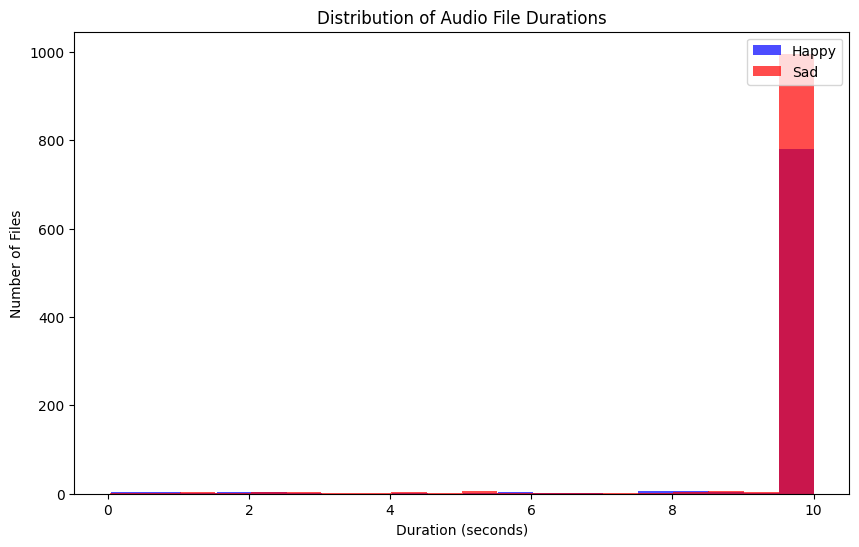

In [ ]:
# Define the paths for happy and sad folders
# Define paths for happy and sad audio
happy_path = '/content/Train/Train/Happy'
sad_path = '/content/Train/Train/Sad'


# Function to get the duration of audio files
def get_audio_duration(file_path):
    y, sr = librosa.load(file_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return duration

# Get durations for happy and sad files
happy_files = [os.path.join(happy_path, f) for f in os.listdir(happy_path) if f.endswith('.wav')]
sad_files = [os.path.join(sad_path, f) for f in os.listdir(sad_path) if f.endswith('.wav')]

happy_durations = [get_audio_duration(f) for f in happy_files]
sad_durations = [get_audio_duration(f) for f in sad_files]

# Plot the duration distribution
plt.figure(figsize=(10, 6))
plt.hist(happy_durations, bins=20, alpha=0.7, label='Happy', color='blue')
plt.hist(sad_durations, bins=20, alpha=0.7, label='Sad', color='red')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Files')
plt.legend(loc='upper right')
plt.title('Distribution of Audio File Durations')
plt.show()

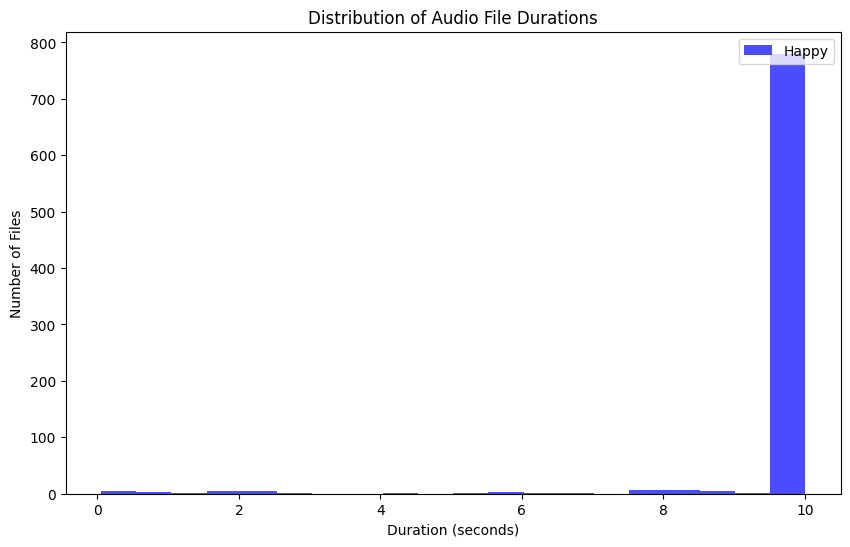

In [ ]:

# Plot the duration distribution
plt.figure(figsize=(10, 6))
plt.hist(happy_durations, bins=20, alpha=0.7, label='Happy', color='blue')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Files')
plt.legend(loc='upper right')
plt.title('Distribution of Audio File Durations')
plt.show()

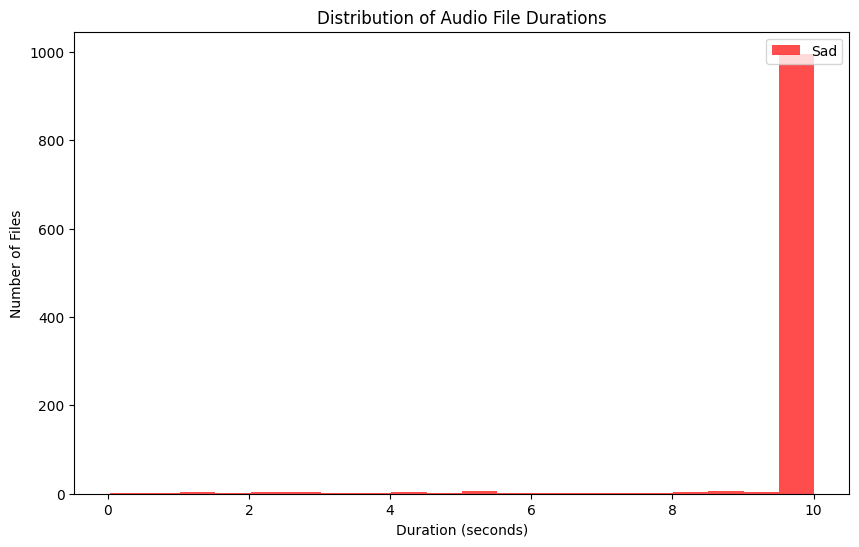

In [ ]:
# Plot the duration distribution
plt.figure(figsize=(10, 6))
plt.hist(sad_durations, bins=20, alpha=0.7, label='Sad', color='red')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Files')
plt.legend(loc='upper right')
plt.title('Distribution of Audio File Durations')
plt.show()

In [ ]:
# Check number of files
print(f"Number of Happy files: {len(happy_files)}")
print(f"Number of Sad files: {len(sad_files)}")

Number of Happy files: 828
Number of Sad files: 1045


#### Play the sample audio

In [ ]:
# Play a sample happy audio
print("Playing a sample happy audio:")
Audio(happy_files[0])

# Play a sample sad audio
print("Playing a sample sad audio:")
Audio(sad_files[0])

Playing a sample happy audio:
Playing a sample sad audio:


### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



#### Visualize sample audio signal using librosa

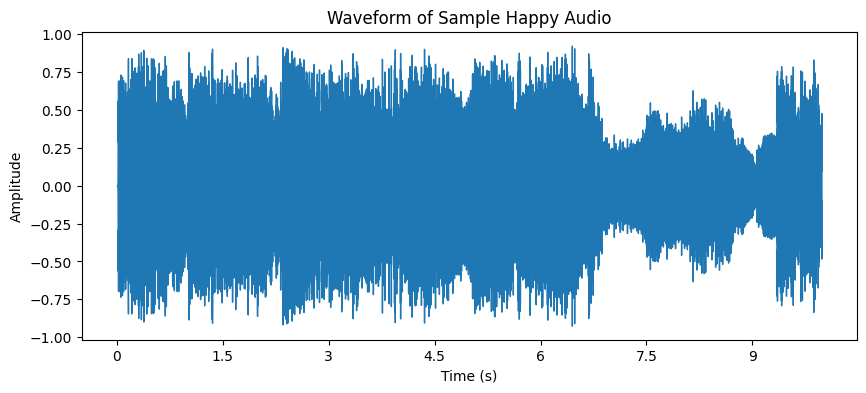

In [ ]:
#sample audio file
sample_audio, sr_sample = librosa.load(happy_files[0], sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(sample_audio, sr=sr_sample)
plt.title('Waveform of Sample Happy Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

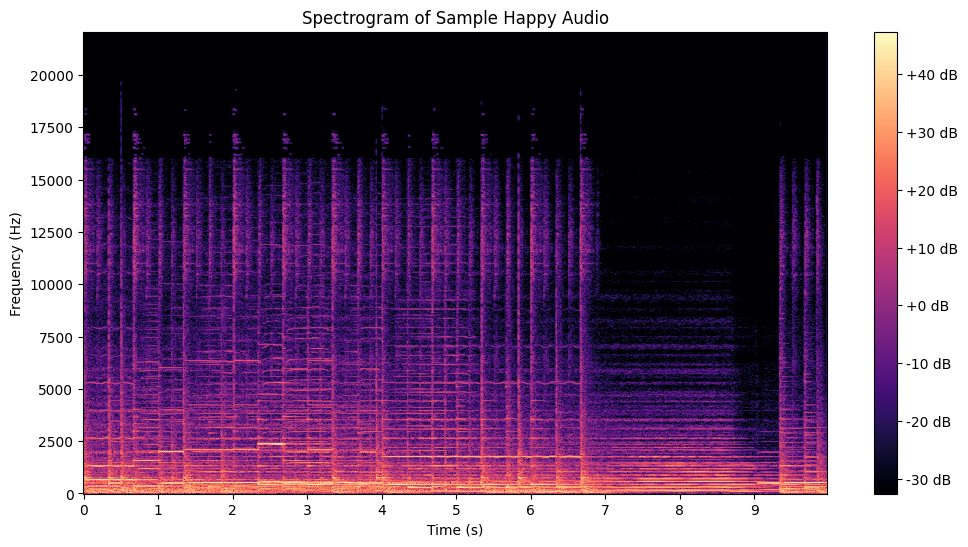

In [ ]:
# Compute and plot spectrogram for the sample audio
S = librosa.stft(sample_audio)
S_db = librosa.amplitude_to_db(abs(S))

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr_sample, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title('Spectrogram of Sample Happy Audio')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

## Preprocess Audio Files (Skip Non-10-Second Files)

In [ ]:
# Function to check if the audio file has a duration of exactly 10 seconds
def is_exactly_10_seconds(file_path, target_duration=10, tolerance=0.01):
    y, sr = librosa.load(file_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    # Check if the duration is within the tolerance range of the target duration
    return abs(duration - target_duration) <= tolerance

# Filter files with exactly 10 seconds duration
def filter_exact_duration(files, target_duration=10, tolerance=0.01):
    valid_files = [file for file in files if is_exactly_10_seconds(file, target_duration, tolerance)]
    return valid_files

# Filter happy and sad files
happy_files_filtered = filter_exact_duration(happy_files)
sad_files_filtered = filter_exact_duration(sad_files)

print(f"Number of valid happy files: {len(happy_files_filtered)}")
print(f"Number of valid sad files: {len(sad_files_filtered)}")

<ipython-input-14-6aa32db2910c>:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-14-6aa32db2910c>:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Number of valid happy files: 630
Number of valid sad files: 784


<ipython-input-18-d23ae0c63c65>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_distribution, x='Emotion', palette='viridis')


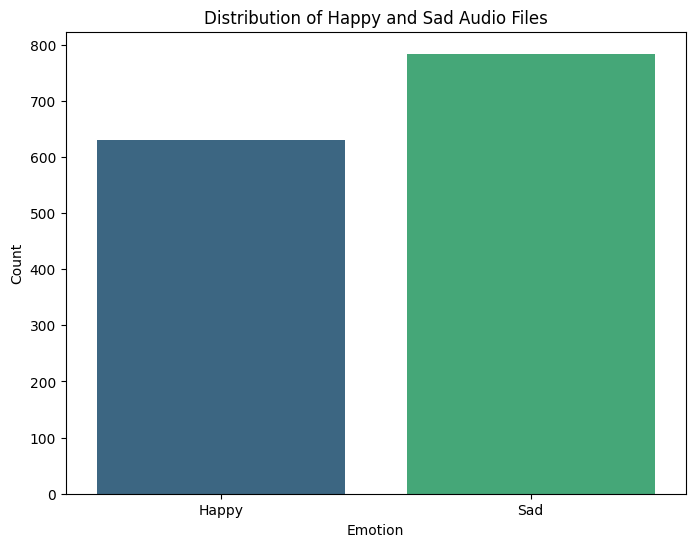

In [ ]:
# Create a DataFrame for visualization
data_distribution = pd.DataFrame({
    'Emotion': ['Happy'] * len(happy_files_filtered) + ['Sad'] * len(sad_files_filtered)
})

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=data_distribution, x='Emotion', palette='viridis')
plt.title('Distribution of Happy and Sad Audio Files')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

# Padding or trimming all files to same duration

In [ ]:
# import librosa
# import numpy as np

# # Function to pad or trim the audio file to a specific duration (in seconds)
# def preprocess_audio(file_path, target_duration=10):
#     y, sr = librosa.load(file_path, sr=None)
#     duration = librosa.get_duration(y=y, sr=sr)

#     if duration < target_duration:
#         # Padding with zeros (silence)
#         padding = target_duration - duration
#         y = np.pad(y, (0, int(padding * sr)), 'constant')
#     elif duration > target_duration:
#         # Trimming to the target duration
#         y = y[:int(target_duration * sr)]

#     return y, sr

# # Example usage for one file
# file_path = happy_files[0]  # Just an example, can loop through all files
# processed_audio, sr = preprocess_audio(file_path)

### **Stage 3:** Feature extraction (2 points)
Extract audio features such as:



*  MFCCs
*  Mel Spectrogram
*   Zero Crossing Rate





In [ ]:
# Feature extraction function
def extract_features(file_list, feature_type="mfcc", n_mfcc=13):
    features = []
    labels = []

    for file_path in file_list:
        y, sr = librosa.load(file_path, sr=None)

        if feature_type == "mfcc":
            feature = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        elif feature_type == "mel":
            feature = librosa.feature.melspectrogram(y=y, sr=sr)
        elif feature_type == "stft":
            feature = np.abs(librosa.stft(y))
        else:
            raise ValueError("Invalid feature type. Choose 'mfcc', 'mel', or 'stft'.")

        feature_mean = np.mean(feature, axis=1)  # Take mean along time axis
        features.append(feature_mean)
        labels.append(0 if "happy" in file_path.lower() else 1)  # Assign 0 for happy, 1 for sad

    return np.array(features), np.array(labels)

# Extract features for both classes
happy_features, happy_labels = extract_features(happy_files_filtered, feature_type="mfcc")
sad_features, sad_labels = extract_features(sad_files_filtered, feature_type="mfcc")

# Combine features and labels
X = np.vstack((happy_features, sad_features))
y = np.hstack((happy_labels, sad_labels))

Feature shape: (1414, 13)
Labels shape: (1414,)


### **Stage 4:** Train the model  (4 points)


In [ ]:
print(f"X shape before split: {X.shape}")
print(f"y shape before split: {y.shape}")

X shape before split: (1414, 13)
y shape before split: (1414,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1131, 13)
y_train shape: (1131,)


In [ ]:
# Reshape X_train and X_test for 1D CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Reshaped X_train shape: {X_train_cnn.shape}")
print(f"Reshaped X_test shape: {X_test_cnn.shape}")


Reshaped X_train shape: (1131, 13, 1)
Reshaped X_test shape: (283, 13, 1)


In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout# Build the 1D CNN model

model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(13, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

In [ ]:

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 11, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 3, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,785 (57.75 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history = model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=20, batch_size=32)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5148 - loss: 4.1658 - val_accuracy: 0.5477 - val_loss: 0.8157
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5238 - loss: 1.8609 - val_accuracy: 0.5300 - val_loss: 0.7090
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5995 - loss: 0.9944 - val_accuracy: 0.5795 - val_loss: 0.6639
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5608 - loss: 0.8644 - val_accuracy: 0.6148 - val_loss: 0.6539
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5761 - loss: 0.7581 - val_accuracy: 0.5830 - val_loss: 0.6729
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5783 - loss: 0.7562 - val_accuracy: 0.6184 - val_loss: 0.6627
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5611 - loss: 0.7428 - val_accuracy: 0.6325 - val_loss: 0.6520
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6007 - loss: 0.7060 - val_accuracy: 0.6148 - val_los

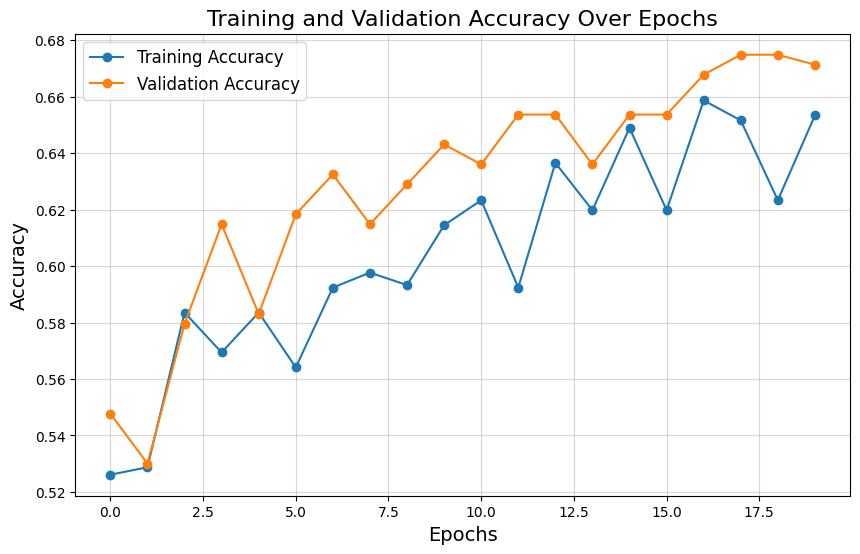

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

## Training and Validation Loss Plot
Shows how the training and validation loss evolve over epochs, helping identify overfitting or underfitting.

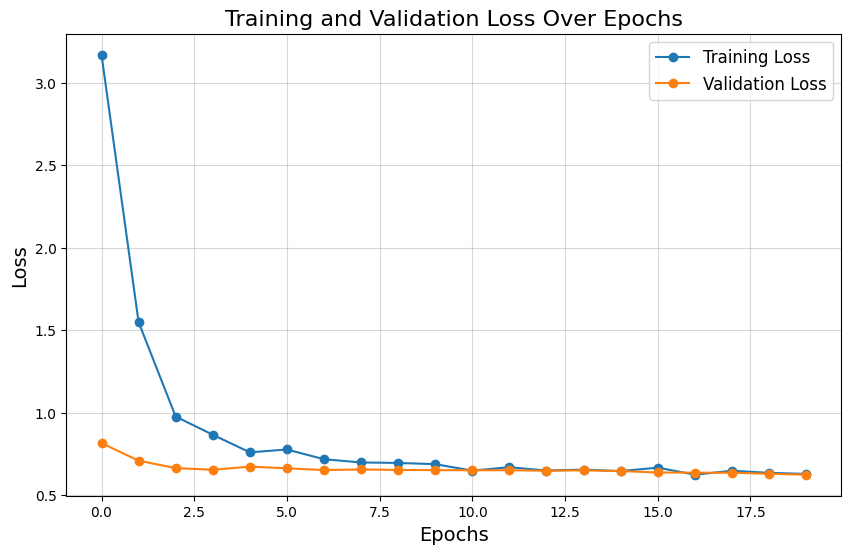

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

## Confusion Matrix
Visualizes how well the model distinguishes between the two classes (e.g., Happy and Sad) on the test set.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for test set
y_pred = (model.predict(X_test_cnn) > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Happy', 'Sad'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)
plt.show()

### Receiver Operating Characteristic (ROC) Curve
Visualizes the trade-off between sensitivity (true positive rate) and specificity (false positive rate).

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test_cnn))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', marker='o')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

## Precision-Recall Curve
Useful for imbalanced datasets, showing the trade-off between precision and recall.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


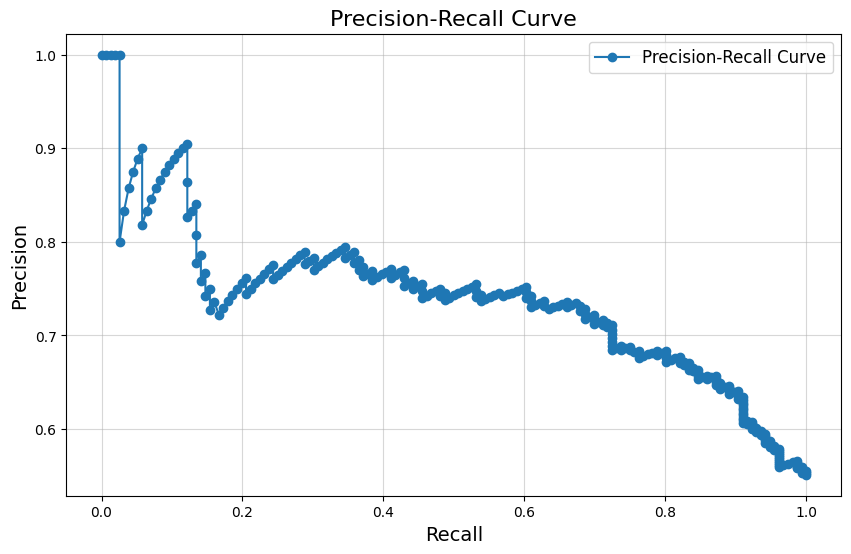

In [ ]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, model.predict(X_test_cnn))

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='o', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.show()

### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [ ]:
# Load test files
test_path = '/content/Test/Test'
test_files = [os.path.join(test_path, file) for file in os.listdir(test_path) if file.endswith('.wav')]
print(f"Number of test files: {len(test_files)}")

# Extract features
test_features = np.array([extract_features(file) for file in test_files])
test_features = test_features.reshape(test_features.shape[0], test_features.shape[1], 1, 1)


Number of test files: 253


<ipython-input-19-3a3be4addce5>:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


IsADirectoryError: [Errno 21] Is a directory: '/'

In [ ]:
# Predict
predictions = model.predict(test_features)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = ['Happy' if cls == 0 else 'Sad' for cls in predicted_classes]

In [ ]:

# Generate submission file
submission = pd.DataFrame({
    'File Name': [os.path.basename(file) for file in test_files],
    'Target': predicted_labels
})
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")